# DNA Classification: Unsupervised Learning

## The business problem

A contract genomics lab receives thousands of DNA reads per week from clients.
Two operational decisions have to be made before any downstream analysis, and
**neither has labeled training data** — nobody has annotated these reads, so
supervised learning is not available.

**Question 1 — Sample routing.** Do incoming sequences fall into natural groups
that would justify separate processing pipelines? Building a routing system
costs engineering time and adds permanent operational complexity, so it only
pays off if the groups are real.

**Question 2 — Quality control.** Which reads are contaminated, truncated, or
artifactual? Bad reads waste compute and corrupt client deliverables. The lab
can afford to manually review about 5% of incoming reads. Which 5%?

Both questions are unsupervised. This notebook answers them with dimensionality
reduction (PCA, t-SNE), clustering (K-Means, Agglomerative), and anomaly
detection.

## What this notebook does

| Part | Method | Business question |
| --- | --- | --- |
| 1. Features | k-mer frequencies, scaling | What represents a read numerically? |
| 2. PCA | Linear projection | Does variance concentrate into structure? |
| 3. t-SNE | Non-linear embedding | Do local neighbourhoods form groups? |
| 4. K-Means | Centroid clustering | How many groups, and how good? |
| 5. Agglomerative | Hierarchical clustering | Does a second algorithm agree? |
| 6. Validation | Silhouette, ARI, gap statistic | Are the groups real or imposed? |
| 7. Anomaly detection | Isolation Forest, LOF, OC-SVM, Elliptic | Which reads should be reviewed? |

**A note on honesty in unsupervised learning.** Clustering algorithms always
return clusters — K-Means with `k=4` returns four groups whether or not four
groups exist. t-SNE always produces visually separated blobs, even on pure
noise. So every result below is accompanied by a validation step that asks
whether the structure found is a property of the data or an artifact of the
method. That distinction is the entire value of the analysis: recommending a
routing system that sorts reads at random would be worse than recommending
nothing.

In [1]:
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    average_precision_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import OneClassSVM

import joblib
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "input").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "input").exists():
    raise FileNotFoundError("Could not locate the project input directory.")

DATA_PATH = PROJECT_ROOT / "input" / "synthetic_dna_dataset.csv"
FIGURES_PATH = PROJECT_ROOT / "reports" / "figures"
OUTPUT_PATH = PROJECT_ROOT / "output"
MODELS_PATH = PROJECT_ROOT / "models"
DETECTOR_PATH = MODELS_PATH / "dna_anomaly_detector.joblib"
for directory in (FIGURES_PATH, OUTPUT_PATH, MODELS_PATH):
    directory.mkdir(parents=True, exist_ok=True)

# The quality-control features live in the project package so the notebook,
# the tests and the Streamlit app all build them the same way.
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from dna_classification.features import (
    QUALITY_FEATURE_NAMES,
    SEQUENCING_ADAPTER,
    extract_quality_features,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

DNA_BASES = ("A", "C", "G", "T")
KMER_SIZE = 3
RANDOM_STATE = 42

# Palette validated for colourblind separation before use: every pair stays
# above the perceptual-difference threshold under deuteranopia, protanopia and
# tritanopia. Gray is the neutral backdrop, orange marks an expectation.
NEUTRAL, HIGHLIGHT, REFERENCE = "#b3b3b3", "#386cb0", "#d95f02"
CLUSTER_COLORS = ["#386cb0", "#E69F00", "#333333", "#8c564b"]

# Part 1 — Representing a read as numbers

Unsupervised methods need a numeric vector per read. The representation used
here is the **3-mer frequency profile**: the relative frequency of each of the
64 possible three-base subsequences. This is the standard composition-based
representation in metagenomics, because organisms differ in which short motifs
they over-use.

Features are standardized so that no single k-mer dominates the distance
calculations that both clustering and t-SNE depend on.

In [2]:
data = pd.read_csv(DATA_PATH)
sequences = data["Sequence"].tolist()
sequence_length = len(sequences[0])

kmer_labels = ["".join(p) for p in product(DNA_BASES, repeat=KMER_SIZE)]
kmer_index = {kmer: i for i, kmer in enumerate(kmer_labels)}

kmer_counts = np.zeros((len(sequences), len(kmer_labels)))
for row, sequence in enumerate(sequences):
    for start in range(sequence_length - KMER_SIZE + 1):
        kmer_counts[row, kmer_index[sequence[start:start + KMER_SIZE]]] += 1
kmer_frequency = kmer_counts / (sequence_length - KMER_SIZE + 1)

scaler = StandardScaler()
X = scaler.fit_transform(kmer_frequency)

print(f"Reads: {len(sequences):,}")
print(f"Read length: {sequence_length} bases")
print(f"Feature matrix: {X.shape[0]:,} reads x {X.shape[1]} 3-mer features")
print(f"Mean after scaling: {X.mean():.2e}   Std after scaling: {X.std():.4f}")
display(
    pd.DataFrame(kmer_frequency, columns=kmer_labels)
    .iloc[:5, :8]
    .round(4)
)

Reads: 3,000
Read length: 100 bases
Feature matrix: 3,000 reads x 64 3-mer features
Mean after scaling: -1.14e-15   Std after scaling: 1.0000


,AAA,AAC,AAG,AAT,ACA,ACC,ACG,ACT
0,0.0204,0.0204,0.0204,0.0102,0.0102,0.0102,0.0102,0.0204
1,0.0204,0.0204,0.0204,0.0204,0.0204,0.0102,0.0204,0.0102
2,0.0306,0.0306,0.0204,0.0102,0.0204,0.0408,0.0102,0.0204
3,0.0000,0.0408,0.0306,0.0000,0.0204,0.0306,0.0204,0.0102
4,0.0102,0.0102,0.0102,0.0204,0.0102,0.0102,0.0000,0.0204


**Analysis.** Each read becomes a point in 64-dimensional space. The first
few columns show that every 3-mer appears at roughly its uniform expectation of
1/64 = 0.0156, which is the first hint of what the rest of the notebook will
confirm. The `Class_Label` column exists in this file but is **not used** for
any fitting step below — it is held back purely as an external check at the end,
which is how unsupervised results should be validated when labels happen to be
available.

# Part 2 — PCA

Principal Component Analysis finds the orthogonal directions of greatest
variance. If reads fall into distinct groups, those groups separate along the
leading components and a small number of components capture most of the
variance.

PC1 explains 4.78% of the variance
PC1 + PC2 explain 9.41%
First 10 components explain 37.08%
Components needed to reach 80% of the variance: 34 of 64
Uniform expectation if variance were spread evenly: 1.56% per component


,component,explained_variance_ratio,cumulative
0,PC1,0.0478,0.0478
1,PC2,0.0462,0.0941
2,PC3,0.0454,0.1395
3,PC4,0.0358,0.1753
4,PC5,0.0350,0.2103


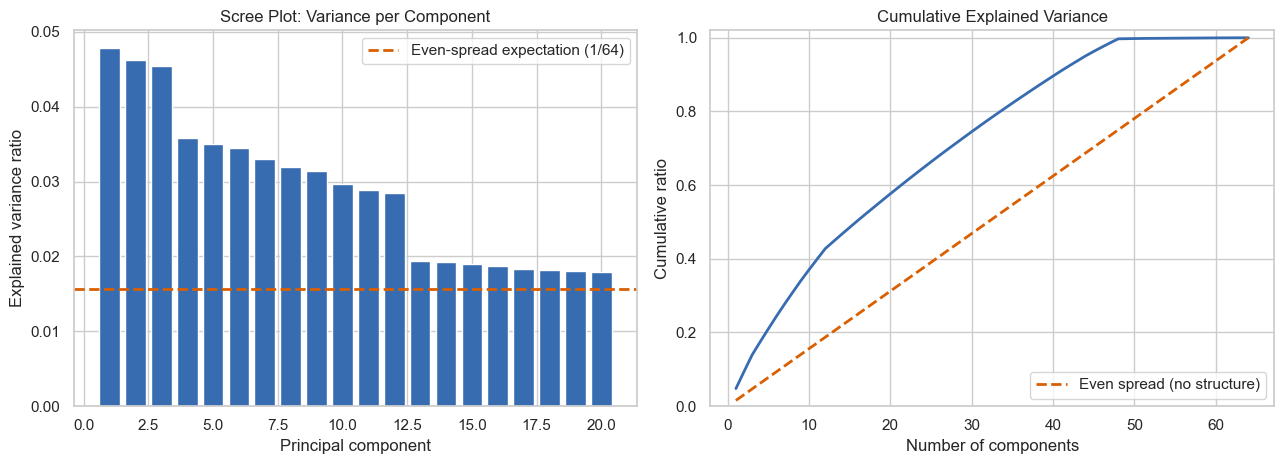

In [3]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

components_for_80 = int(np.searchsorted(cumulative, 0.80) + 1)
print(f"PC1 explains {explained[0]:.2%} of the variance")
print(f"PC1 + PC2 explain {cumulative[1]:.2%}")
print(f"First 10 components explain {cumulative[9]:.2%}")
print(f"Components needed to reach 80% of the variance: {components_for_80} of {X.shape[1]}")
print(f"Uniform expectation if variance were spread evenly: {1 / X.shape[1]:.2%} per component")

display(
    pd.DataFrame(
        {
            "component": [f"PC{i + 1}" for i in range(5)],
            "explained_variance_ratio": explained[:5],
            "cumulative": cumulative[:5],
        }
    ).round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].bar(range(1, 21), explained[:20], color=HIGHLIGHT)
axes[0].axhline(
    1 / X.shape[1],
    color=REFERENCE,
    linestyle="--",
    linewidth=2,
    label="Even-spread expectation (1/64)",
)
axes[0].set(
    title="Scree Plot: Variance per Component",
    xlabel="Principal component",
    ylabel="Explained variance ratio",
)
axes[0].legend()

axes[1].plot(range(1, len(cumulative) + 1), cumulative, color=HIGHLIGHT, linewidth=2)
axes[1].plot(
    range(1, len(cumulative) + 1),
    np.arange(1, len(cumulative) + 1) / X.shape[1],
    color=REFERENCE,
    linestyle="--",
    linewidth=2,
    label="Even spread (no structure)",
)
axes[1].set(
    title="Cumulative Explained Variance",
    xlabel="Number of components",
    ylabel="Cumulative ratio",
    ylim=(0, 1.02),
)
axes[1].legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_pca_scree.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** The scree plot is nearly flat. PC1 captures 4.8% of the
variance against the 1.6% a component would capture if variance were spread
perfectly evenly, and the decline across components is gradual rather than
showing the sharp elbow that indicates real structure. Reaching 80% of the
variance takes 34 of the 64 components.

The cumulative curve tells the same story: it tracks close to the diagonal that
represents no structure at all. A dataset with genuine groups produces a curve
that rises steeply and then flattens — a handful of components explaining most
of the variance. Here the information is spread almost uniformly across all
directions, which is the signature of a high-dimensional noise cloud rather
than of clustered data.

## The PCA projection

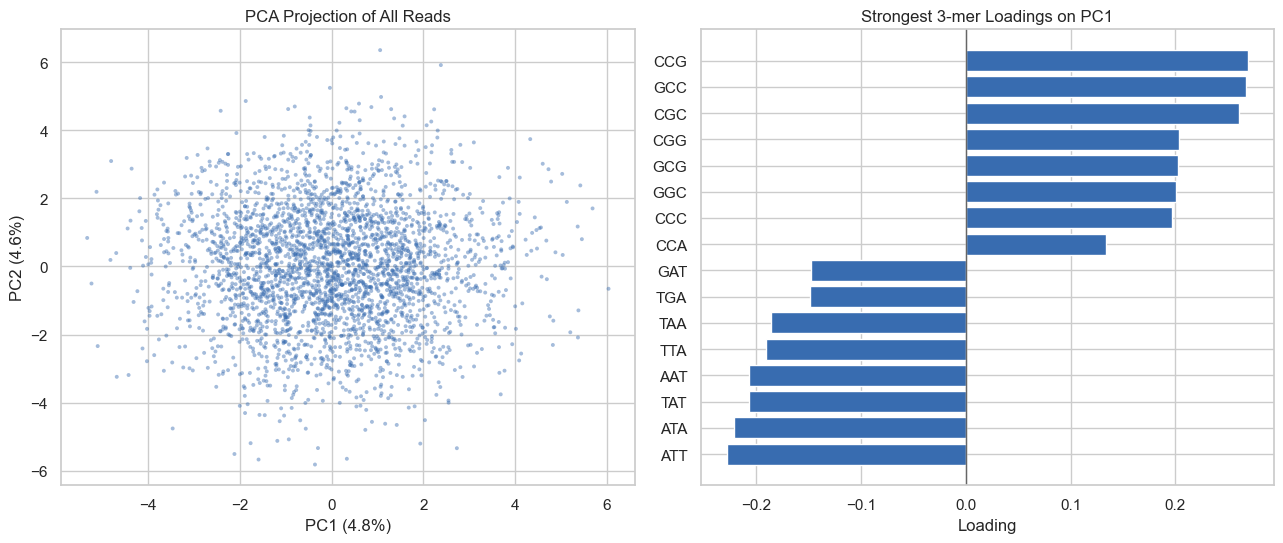

Largest absolute PC1 loading: 0.2692
If all 64 k-mers contributed equally: 0.1250


In [4]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))
axes[0].scatter(
    pca_coords[:, 0], pca_coords[:, 1], s=8, color=HIGHLIGHT, alpha=0.45,
    edgecolors="none",
)
axes[0].set(
    title="PCA Projection of All Reads",
    xlabel=f"PC1 ({explained[0]:.1%})",
    ylabel=f"PC2 ({explained[1]:.1%})",
)

loadings = pd.Series(pca.components_[0], index=kmer_labels).sort_values()
extreme = pd.concat([loadings.head(8), loadings.tail(8)])
axes[1].barh(extreme.index, extreme.to_numpy(), color=HIGHLIGHT)
axes[1].axvline(0, color="#666666", linewidth=1)
axes[1].set(
    title="Strongest 3-mer Loadings on PC1",
    xlabel="Loading",
    ylabel="",
)
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_pca_projection.png", dpi=160, bbox_inches="tight")
plt.show()

print(f"Largest absolute PC1 loading: {np.abs(pca.components_[0]).max():.4f}")
print(f"If all 64 k-mers contributed equally: {1 / np.sqrt(64):.4f}")

**Analysis.** The projection is a single, roughly circular cloud with one
centre and no gaps, lobes, or satellite groups. This is what a multivariate
Gaussian blob looks like when projected onto two dimensions.

The loadings panel explains why. If a real biological group existed, PC1 would
be driven by a handful of k-mers characteristic of that group, and their
loadings would dominate. Instead the largest absolute loading is close to the
value every k-mer would have if all 64 contributed equally, meaning PC1 is an
arbitrary direction through a spherical cloud rather than an axis of biological
contrast.

# Part 3 — t-SNE

PCA is linear and can miss structure that is curved or locally organized. t-SNE
embeds points so that near neighbours in the original space stay near in two
dimensions, and it is far more sensitive to local grouping.

**t-SNE needs a control.** The algorithm is famous for producing visually
convincing islands even when the input is pure noise, because it optimizes a
local-neighbourhood objective that will always find *some* arrangement. So the
real data is embedded alongside a **permuted control**: the same matrix with
each feature column independently shuffled, which destroys any joint structure
while preserving every individual feature's distribution. If the two pictures
look alike, the structure in the first one is an artifact of the method.

scikit-learn uses 'n_iter' for the t-SNE iteration count
Running t-SNE on the real data (perplexity=30)...
Running t-SNE on the permuted control...
Done.


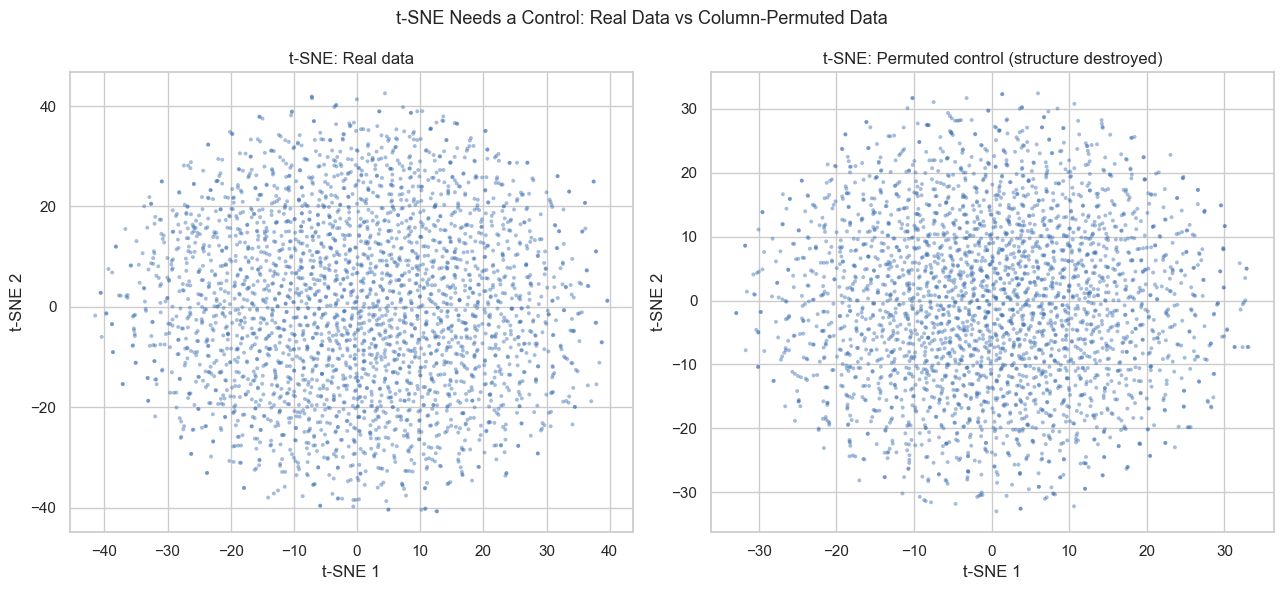

In [5]:
TSNE_PERPLEXITY = 30

# scikit-learn renamed TSNE's iteration argument from n_iter to max_iter in
# version 1.5 and deprecated the old name. Picking it from the signature keeps
# this cell working on either version instead of failing on whichever one the
# reader happens to have installed.
import inspect

tsne_iteration_argument = (
    "max_iter"
    if "max_iter" in inspect.signature(TSNE.__init__).parameters
    else "n_iter"
)
tsne_kwargs = {
    "n_components": 2,
    "perplexity": TSNE_PERPLEXITY,
    "init": "pca",
    "learning_rate": "auto",
    tsne_iteration_argument: 1000,
    "random_state": RANDOM_STATE,
}
print(f"scikit-learn uses '{tsne_iteration_argument}' for the t-SNE iteration count")

generator = np.random.default_rng(RANDOM_STATE)
X_permuted = np.column_stack(
    [generator.permutation(X[:, column]) for column in range(X.shape[1])]
)

print(f"Running t-SNE on the real data (perplexity={TSNE_PERPLEXITY})...")
tsne_real = TSNE(**tsne_kwargs).fit_transform(X)
print("Running t-SNE on the permuted control...")
tsne_control = TSNE(**tsne_kwargs).fit_transform(X_permuted)
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False)
for ax, coords, title in zip(
    axes,
    (tsne_real, tsne_control),
    ("Real data", "Permuted control (structure destroyed)"),
):
    ax.scatter(
        coords[:, 0], coords[:, 1], s=8, color=HIGHLIGHT, alpha=0.45,
        edgecolors="none",
    )
    ax.set(title=f"t-SNE: {title}", xlabel="t-SNE 1", ylabel="t-SNE 2")
fig.suptitle(
    "t-SNE Needs a Control: Real Data vs Column-Permuted Data", fontsize=13
)
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_tsne_control.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** The two panels are interchangeable. Both show the same diffuse,
roughly circular spread with the same grainy local texture and the same absence
of separated islands. Since the right-hand panel has had every trace of joint
structure destroyed by permutation, whatever texture appears in the left-hand
panel is produced by t-SNE itself, not found in the data.

This is the single most useful control in the notebook. Without it, a reader
could squint at the left panel, see local density variations, and conclude that
groups exist. Placing the control beside it removes that temptation. **Any t-SNE
plot presented as evidence of clusters should come with a control like this
one** — the method's own documentation warns that cluster sizes, distances
between clusters, and apparent gaps are frequently meaningless.

# Part 4 — K-Means

K-Means partitions the reads into `k` groups by minimizing within-cluster
variance. It always succeeds at producing `k` groups, so the question is not
whether it runs but whether the partition it returns is meaningful.

The scan below fits `k` from 2 to 10 and records four diagnostics:

- **Inertia** — within-cluster sum of squares; used for the elbow heuristic.
- **Silhouette** — how much closer a point is to its own cluster than to the
  next nearest, from -1 to 1. Above 0.5 indicates reasonable structure; near 0
  means clusters overlap completely.
- **Calinski-Harabasz** — between-cluster over within-cluster dispersion; higher
  is better.
- **Davies-Bouldin** — average similarity between each cluster and its most
  similar one; lower is better.

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,186051.2611,0.0299,95.8570,5.5582
1,3,181948.3978,0.0266,82.7835,4.9060
2,4,178746.3817,0.0255,74.0488,4.5328
3,5,176616.4840,0.0242,65.2171,4.5282
4,6,174615.1699,0.0238,59.6170,4.3243
5,7,173057.3827,0.0234,54.6016,4.2453
6,8,171660.1540,0.0236,50.6456,4.2052
7,9,170288.7167,0.0233,47.6679,4.0932
8,10,169141.9211,0.0231,44.8970,4.0622


Best silhouette: 0.0299 at k=2
Interpretation scale: >0.7 strong, 0.5-0.7 reasonable, 0.25-0.5 weak, <0.25 none


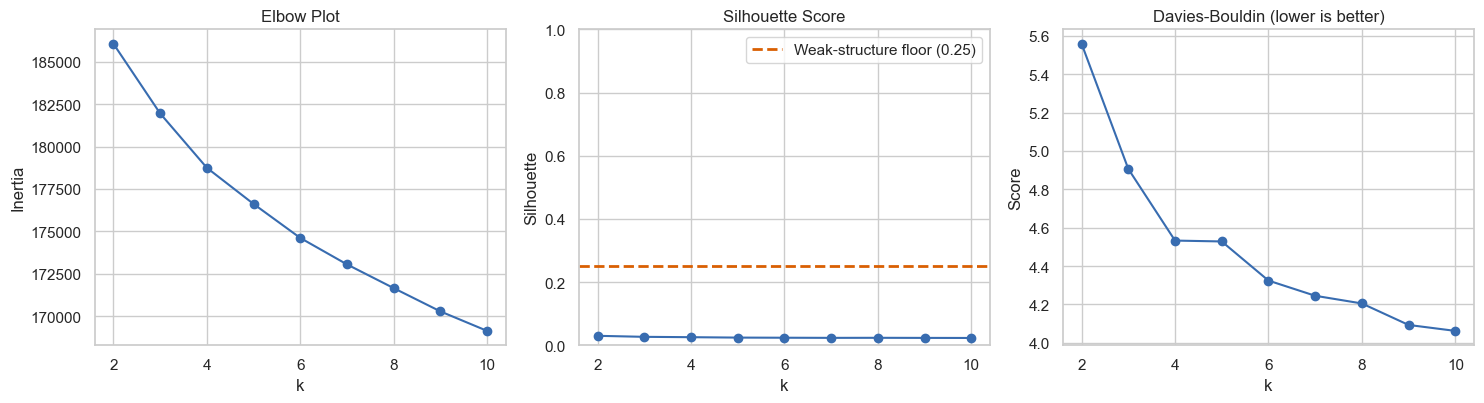

In [6]:
kmeans_rows = []
kmeans_models = {}
for k in range(2, 11):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    kmeans_models[k] = model
    kmeans_rows.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(
                X, model.labels_, sample_size=2000, random_state=RANDOM_STATE
            ),
            "calinski_harabasz": calinski_harabasz_score(X, model.labels_),
            "davies_bouldin": davies_bouldin_score(X, model.labels_),
        }
    )

kmeans_table = pd.DataFrame(kmeans_rows)
display(kmeans_table.round(4))
best_k = int(kmeans_table.loc[kmeans_table["silhouette"].idxmax(), "k"])
best_silhouette = kmeans_table["silhouette"].max()
print(f"Best silhouette: {best_silhouette:.4f} at k={best_k}")
print("Interpretation scale: >0.7 strong, 0.5-0.7 reasonable, 0.25-0.5 weak, <0.25 none")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].plot(kmeans_table["k"], kmeans_table["inertia"], "o-", color=HIGHLIGHT)
axes[0].set(title="Elbow Plot", xlabel="k", ylabel="Inertia")
axes[1].plot(kmeans_table["k"], kmeans_table["silhouette"], "o-", color=HIGHLIGHT)
axes[1].axhline(
    0.25, color=REFERENCE, linestyle="--", linewidth=2,
    label="Weak-structure floor (0.25)",
)
axes[1].set(title="Silhouette Score", xlabel="k", ylabel="Silhouette", ylim=(0, 1))
axes[1].legend()
axes[2].plot(
    kmeans_table["k"], kmeans_table["davies_bouldin"], "o-", color=HIGHLIGHT
)
axes[2].set(title="Davies-Bouldin (lower is better)", xlabel="k", ylabel="Score")
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_kmeans_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** All three diagnostics agree, and they agree on "no structure".

The elbow plot has no elbow: inertia falls smoothly and almost linearly as `k`
rises, which is what happens when a partition simply subdivides one homogeneous
cloud. There is no `k` at which adding a cluster stops paying off, because no
`k` is right.

The silhouette score peaks at about **0.03**, far below the 0.25 floor that
would indicate even weak structure. A score this close to zero means the average
read is essentially as close to a neighbouring cluster as to its own. Davies-
Bouldin sits between 4 and 5.5, where values near or below 1 would be expected
for separated clusters, and it improves monotonically with `k` — another sign of
arbitrary subdivision rather than discovery.

Note that the silhouette is *highest* at `k=2` and decreases from there. Taken
naively this would "select" two clusters. The absolute value is what matters,
and 0.03 is indistinguishable from a random partition.

## Visualizing the K-Means partition

,cluster,reads,percent
0,0,716,23.87
1,1,777,25.90
2,2,774,25.80
3,3,733,24.43


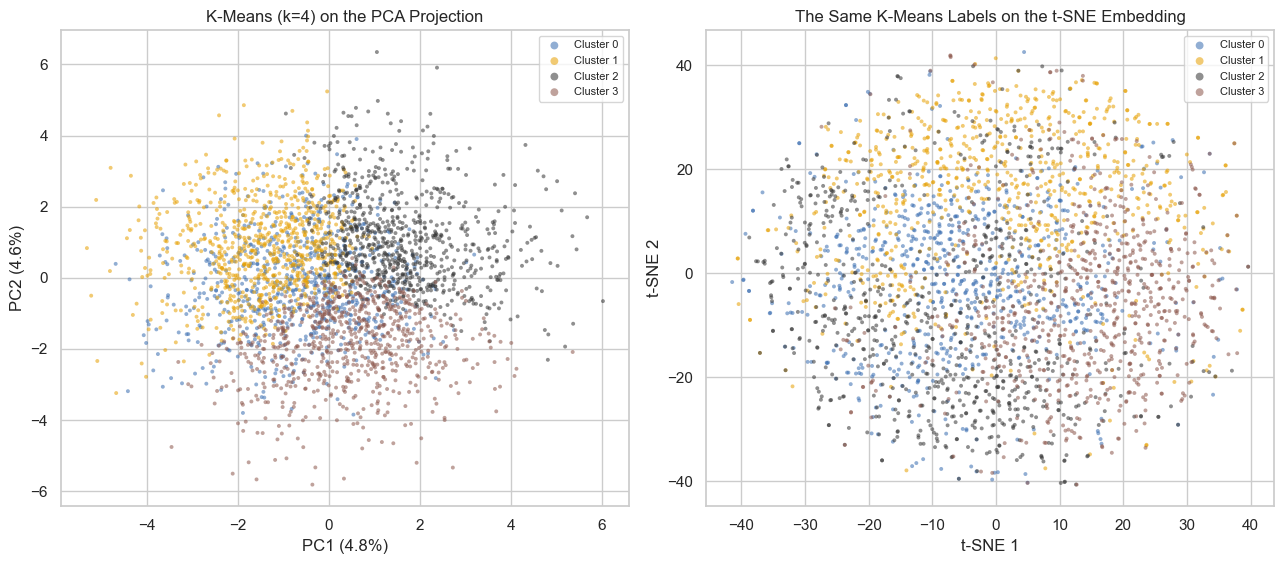

In [7]:
CHOSEN_K = 4
kmeans_final = kmeans_models[CHOSEN_K]
kmeans_labels = kmeans_final.labels_

cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
display(
    pd.DataFrame(
        {
            "cluster": cluster_sizes.index,
            "reads": cluster_sizes.to_numpy(),
            "percent": (cluster_sizes / len(X) * 100).round(2).to_numpy(),
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
for cluster in range(CHOSEN_K):
    mask = kmeans_labels == cluster
    axes[0].scatter(
        pca_coords[mask, 0], pca_coords[mask, 1], s=8, alpha=0.55,
        color=CLUSTER_COLORS[cluster], edgecolors="none",
        label=f"Cluster {cluster}",
    )
    axes[1].scatter(
        tsne_real[mask, 0], tsne_real[mask, 1], s=8, alpha=0.55,
        color=CLUSTER_COLORS[cluster], edgecolors="none",
        label=f"Cluster {cluster}",
    )
axes[0].set(
    title=f"K-Means (k={CHOSEN_K}) on the PCA Projection",
    xlabel=f"PC1 ({explained[0]:.1%})",
    ylabel=f"PC2 ({explained[1]:.1%})",
)
axes[1].set(
    title=f"The Same K-Means Labels on the t-SNE Embedding",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
)
for ax in axes:
    ax.legend(markerscale=2, fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_kmeans_projection.png", dpi=160, bbox_inches="tight")
plt.show()

**Analysis.** The two panels show the same partition in two projections, and
together they are diagnostic.

On the PCA projection the clusters appear as clean wedges meeting at the centre
of the cloud. That shape is the giveaway: K-Means draws straight boundaries
through whatever it is given, so slicing a spherical cloud produces exactly
these pie-slice regions. Real clusters appear as separated blobs, not as
contiguous sectors of one blob.

On the t-SNE embedding the same labels form broad, heavily overlapping
gradients rather than separated islands. Each cluster leans toward one side of
the cloud — unavoidable, since K-Means carves contiguous regions in the original
space and t-SNE partially preserves that arrangement — but there are no
boundaries, no gaps, and no region belongs exclusively to one cluster. Colours
bleed into each other continuously across the whole embedding.

That continuity is the point. On genuinely grouped data t-SNE places each
cluster in its own island with visible empty space between them, so cluster
membership and embedding position agree sharply. Here they agree only in the
weak sense that a smooth gradient has a left and a right: one cloud, tinted by
an arbitrary partition.

# Part 5 — Agglomerative clustering

Hierarchical agglomerative clustering starts with every read as its own cluster
and repeatedly merges the closest pair. It makes different assumptions than
K-Means — no centroids, no assumption of spherical clusters — so it is a genuine
second opinion rather than a restatement.

The dendrogram shows the merge history. Real groups appear as branches that
merge late at a large height, separated by a long vertical gap from the merges
below them.

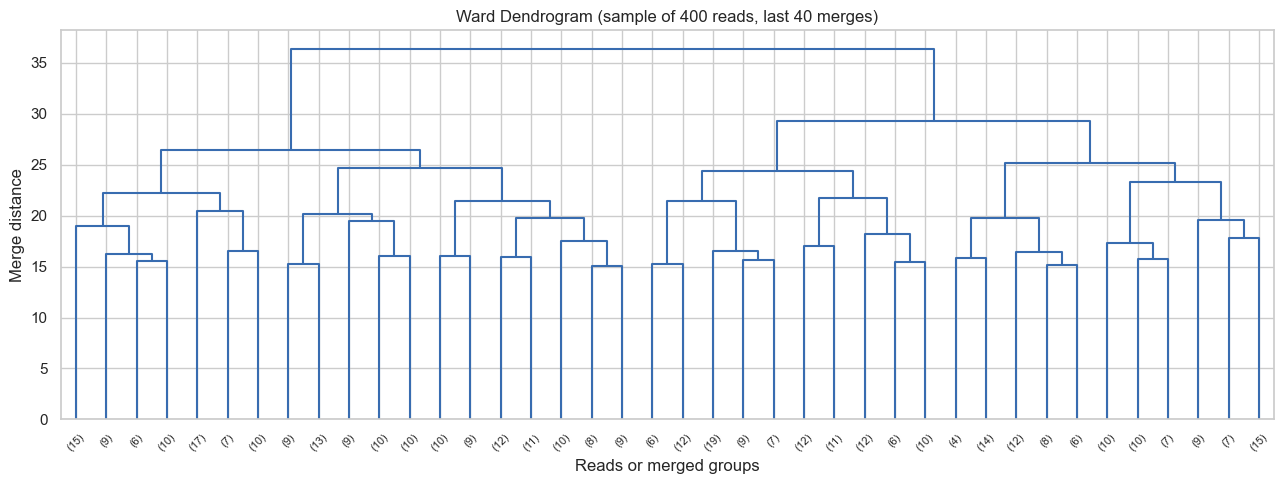

Largest gap among the final 15 merges: 7.0922
Mean merge height of those merges:     23.7742
Largest gap as a share of that height:  29.83%


In [8]:
DENDROGRAM_SAMPLE = 400
sample_index = np.random.default_rng(RANDOM_STATE).choice(
    len(X), size=DENDROGRAM_SAMPLE, replace=False
)
linkage_matrix = linkage(X[sample_index], method="ward")

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=40,
    ax=ax,
    color_threshold=0,
    above_threshold_color=HIGHLIGHT,
)
ax.set(
    title=f"Ward Dendrogram (sample of {DENDROGRAM_SAMPLE} reads, last 40 merges)",
    xlabel="Reads or merged groups",
    ylabel="Merge distance",
)
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_dendrogram.png", dpi=160, bbox_inches="tight")
plt.show()

merge_heights = linkage_matrix[:, 2]
top_gaps = np.diff(merge_heights[-15:])
print(f"Largest gap among the final 15 merges: {top_gaps.max():.4f}")
print(f"Mean merge height of those merges:     {merge_heights[-15:].mean():.4f}")
print(
    f"Largest gap as a share of that height:  "
    f"{top_gaps.max() / merge_heights[-15:].mean():.2%}"
)

**Analysis.** The dendrogram rises smoothly with no dominant split. Merge
heights increase gradually all the way to the root, and the largest gap among
the final merges is a small fraction of the height at which those merges happen.

A dataset with real groups produces a visibly different picture: a few tall
branches separated by a large vertical gap, so that cutting the tree anywhere in
that gap yields the same clusters. Here there is no such gap, meaning the number
of clusters you get depends entirely on where you choose to cut — which is
another way of saying the data does not contain a natural number of groups.

,cluster,reads,percent
0,0,1060,35.33
1,1,925,30.83
2,2,616,20.53
3,3,399,13.30


Agglomerative silhouette at k=4: 0.0045


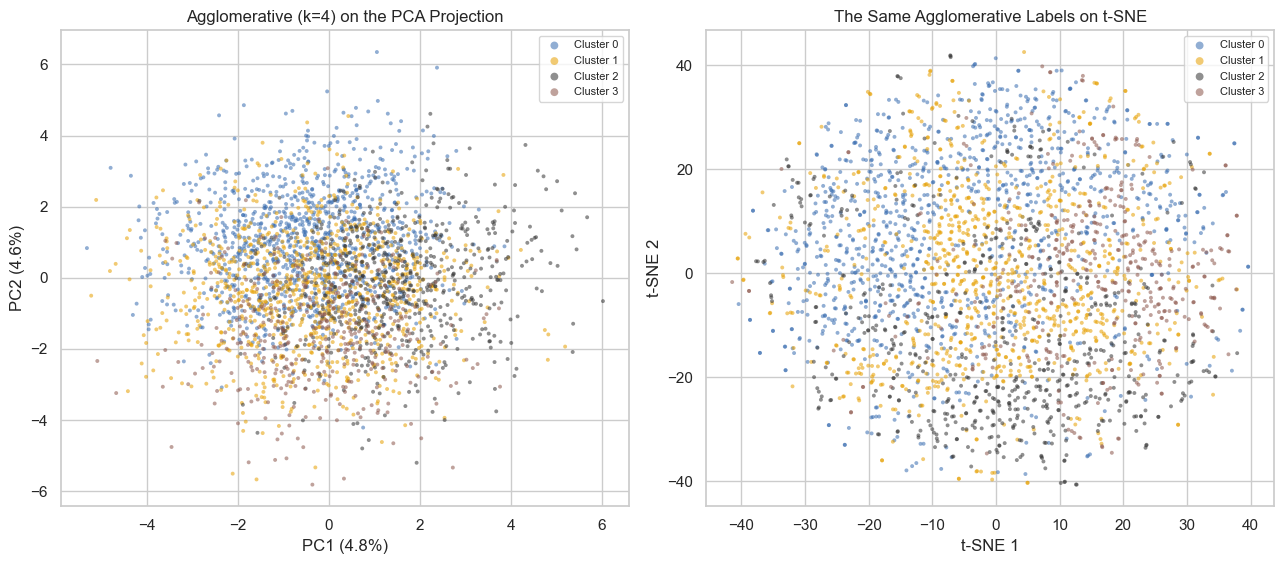

In [9]:
agglomerative = AgglomerativeClustering(n_clusters=CHOSEN_K, linkage="ward")
agglomerative_labels = agglomerative.fit_predict(X)

agglomerative_sizes = pd.Series(agglomerative_labels).value_counts().sort_index()
display(
    pd.DataFrame(
        {
            "cluster": agglomerative_sizes.index,
            "reads": agglomerative_sizes.to_numpy(),
            "percent": (agglomerative_sizes / len(X) * 100).round(2).to_numpy(),
        }
    )
)
print(
    f"Agglomerative silhouette at k={CHOSEN_K}: "
    f"{silhouette_score(X, agglomerative_labels, sample_size=2000, random_state=RANDOM_STATE):.4f}"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
for cluster in range(CHOSEN_K):
    mask = agglomerative_labels == cluster
    axes[0].scatter(
        pca_coords[mask, 0], pca_coords[mask, 1], s=8, alpha=0.55,
        color=CLUSTER_COLORS[cluster], edgecolors="none",
        label=f"Cluster {cluster}",
    )
    axes[1].scatter(
        tsne_real[mask, 0], tsne_real[mask, 1], s=8, alpha=0.55,
        color=CLUSTER_COLORS[cluster], edgecolors="none",
        label=f"Cluster {cluster}",
    )
axes[0].set(
    title=f"Agglomerative (k={CHOSEN_K}) on the PCA Projection",
    xlabel=f"PC1 ({explained[0]:.1%})",
    ylabel=f"PC2 ({explained[1]:.1%})",
)
axes[1].set(
    title="The Same Agglomerative Labels on t-SNE",
    xlabel="t-SNE 1",
    ylabel="t-SNE 2",
)
for ax in axes:
    ax.legend(markerscale=2, fontsize=8, loc="upper right")
fig.tight_layout()
fig.savefig(
    FIGURES_PATH / "unsup_agglomerative_projection.png", dpi=160, bbox_inches="tight"
)
plt.show()

**Analysis.** Agglomerative clustering carves the cloud differently from
K-Means, and the difference is structural rather than cosmetic.

K-Means produced clean geometric wedges on the PCA projection, because
minimizing distance to centroids partitions space into Voronoi cells with
straight boundaries. Ward linkage has no centroids and no such constraint, so
its clusters overlap substantially even on PCA: cluster 0 spreads across the
whole cloud while the others interleave through it. On t-SNE the labels are more
thoroughly mixed than the K-Means labels were.

**Two competent algorithms, the same data, structurally different answers.**
That is the finding, and the next part quantifies it. On genuinely grouped data
both methods would recover nearly the same partition, because the grouping would
be a property of the data that any reasonable method must find. On a homogeneous
cloud each method imposes the division its own objective function prefers, and
those divisions have no reason to agree.

# Part 6 — Validation: are these clusters real?

Three independent checks, none of which depends on the class labels.

**Check 1 — Do the algorithms agree with each other?** The Adjusted Rand Index
measures partition agreement, corrected for chance: 1.0 is identical, 0.0 is
what two random partitions score. Real structure forces agreement.

**Check 2 — Is there density structure?** DBSCAN groups points by density and
labels sparse regions as noise rather than forcing every point into a cluster.
On data with real groups it finds them; on a uniform cloud it either calls
everything noise or lumps everything into one cluster, depending on the radius.

**Check 3 — The gap statistic.** This compares the within-cluster dispersion of
the real data against a reference with no joint structure. The reference here is
the **column-permuted** matrix, which preserves every feature's own distribution
while destroying relationships between features. A dataset with real clusters
shows a gap that rises and then peaks at the correct `k`.

In [10]:
print("Check 1 - agreement between clustering algorithms (Adjusted Rand Index)")
ari_algorithms = adjusted_rand_score(kmeans_labels, agglomerative_labels)
ari_kmeans_class = adjusted_rand_score(data["Class_Label"], kmeans_labels)
ari_agglomerative_class = adjusted_rand_score(
    data["Class_Label"], agglomerative_labels
)
display(
    pd.DataFrame(
        [
            {"comparison": "K-Means vs Agglomerative", "adjusted_rand_index": ari_algorithms},
            {"comparison": "K-Means vs Class_Label", "adjusted_rand_index": ari_kmeans_class},
            {"comparison": "Agglomerative vs Class_Label", "adjusted_rand_index": ari_agglomerative_class},
        ]
    ).round(5)
)
print("ARI scale: 1.0 identical, 0.0 = chance agreement between random partitions")

print()
print("Check 2 - DBSCAN density structure")
dbscan_rows = []
for eps in (3.0, 5.0, 7.0, 9.0):
    labels = DBSCAN(eps=eps, min_samples=10).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = int((labels == -1).sum())
    dbscan_rows.append(
        {
            "eps": eps,
            "clusters_found": n_clusters,
            "noise_points": noise,
            "noise_share": noise / len(X),
        }
    )
display(pd.DataFrame(dbscan_rows).round(4))

Check 1 - agreement between clustering algorithms (Adjusted Rand Index)


,comparison,adjusted_rand_index
0,K-Means vs Agglomerative,0.12951
1,K-Means vs Class_Label,0.00124
2,Agglomerative vs Class_Label,-0.00002


ARI scale: 1.0 identical, 0.0 = chance agreement between random partitions

Check 2 - DBSCAN density structure


,eps,clusters_found,noise_points,noise_share
0,3.0,0,3000,1.0000
1,5.0,0,3000,1.0000
2,7.0,2,2961,0.9870
3,9.0,1,29,0.0097


Check 3 - gap statistic against a column-permuted reference


,k,log_inertia_real,log_inertia_reference,gap,s_k
0,2,12.13378,12.15202,0.01824,0.00017
1,3,12.11148,12.14234,0.03086,0.00034
2,4,12.09372,12.13450,0.04078,0.00031
3,5,12.08174,12.12796,0.04623,0.00022
4,6,12.07034,12.12206,0.05172,0.00026
5,7,12.06138,12.11619,0.05481,0.00035
6,8,12.05327,12.11124,0.05796,0.00069
7,9,12.04525,12.10624,0.06099,0.00048
8,10,12.03849,12.10196,0.06347,0.00027


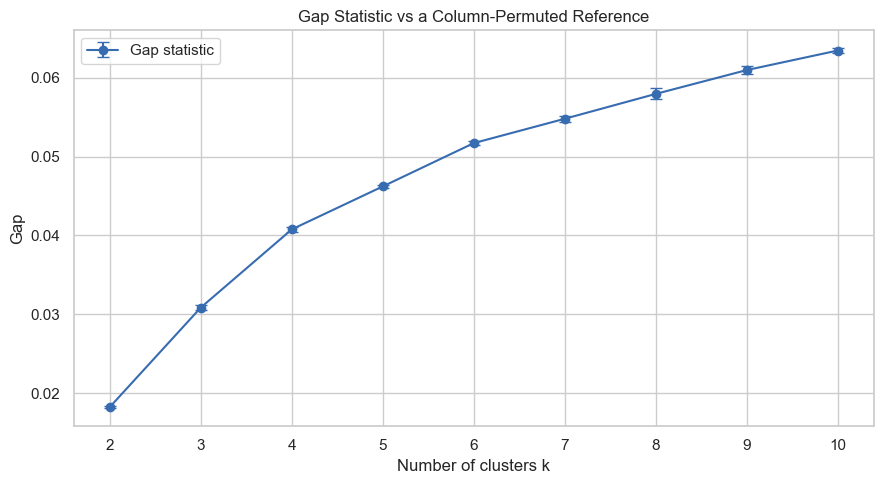

A dataset with real clusters produces a gap that peaks at the correct k.
Here the gap rises monotonically from 0.0182 to 0.0635 with no maximum.


In [11]:
print("Check 3 - gap statistic against a column-permuted reference")
N_REFERENCES = 5
gap_rows = []
gap_generator = np.random.default_rng(RANDOM_STATE)
for k in range(2, 11):
    log_real = np.log(
        KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X).inertia_
    )
    reference_logs = []
    for _ in range(N_REFERENCES):
        X_reference = np.column_stack(
            [gap_generator.permutation(X[:, column]) for column in range(X.shape[1])]
        )
        reference_logs.append(
            np.log(
                KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
                .fit(X_reference)
                .inertia_
            )
        )
    reference_logs = np.array(reference_logs)
    gap_rows.append(
        {
            "k": k,
            "log_inertia_real": log_real,
            "log_inertia_reference": reference_logs.mean(),
            "gap": reference_logs.mean() - log_real,
            "s_k": reference_logs.std() * np.sqrt(1 + 1 / N_REFERENCES),
        }
    )

gap_table = pd.DataFrame(gap_rows)
display(gap_table.round(5))

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(
    gap_table["k"], gap_table["gap"], yerr=gap_table["s_k"],
    fmt="o-", color=HIGHLIGHT, capsize=4, label="Gap statistic",
)
ax.set(
    title="Gap Statistic vs a Column-Permuted Reference",
    xlabel="Number of clusters k",
    ylabel="Gap",
)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_gap_statistic.png", dpi=160, bbox_inches="tight")
plt.show()

print(
    "A dataset with real clusters produces a gap that peaks at the correct k."
)
print(
    f"Here the gap rises monotonically from {gap_table['gap'].iloc[0]:.4f} "
    f"to {gap_table['gap'].iloc[-1]:.4f} with no maximum."
)

**Analysis.** All three checks return the same verdict.

**Agreement.** K-Means and Agglomerative reach an ARI of about **0.13** with
each other — barely above the 0.0 that two random partitions would score. Two
competent algorithms looking at the same data disagree about which reads belong
together, which is only possible when the grouping is imposed rather than found.
Against the withheld `Class_Label`, both score essentially **0.00**: the
clusters carry no information about the biological class either.

**Density.** DBSCAN never finds a sensible middle ground. At small radii it
labels every read as noise; at a large radius it collapses everything into a
single cluster containing about 99% of the reads. There is no radius that
separates dense regions, because there are no dense regions — the cloud has
uniform density throughout.

**Gap statistic.** The gap is small and rises monotonically with `k`, never
peaking. A real cluster count would show a clear maximum. The steady rise simply
reflects that K-Means fits real data marginally better than permuted data at
every `k`, with no `k` preferred over any other.

Note how this differs from the naive gap statistic using a uniform reference,
which would report a large positive gap here purely because a roughly Gaussian
cloud is more compact than a uniform box. Choosing the permuted reference makes
the test answer the question actually being asked: *is there joint structure
beyond what the individual features already imply?*

## Business decision on Question 1

**Do not build the routing system.**

The evidence is consistent across every method applied: PCA finds no
concentration of variance, t-SNE is indistinguishable from its permuted control,
K-Means silhouette peaks at 0.03, the dendrogram has no dominant split, DBSCAN
finds no density structure, the gap statistic never peaks, and the two
clustering algorithms agree with each other at ARI 0.13.

Any routing rule derived from these clusters would sort incoming reads
essentially at random while carrying the full engineering and maintenance cost
of a real system, plus the ongoing risk that someone downstream mistakes the
cluster id for a meaningful attribute. **Recommending against the build is the
valuable output here** — a negative result that is properly evidenced saves the
budget it would have consumed.

This conclusion is about *this* dataset. The same notebook run against reads
from a genuine mixed-organism sample would be expected to separate cleanly on GC
content and k-mer composition alone, which is precisely why metagenomic binning
works in practice.

# Part 7 — Where unsupervised learning does deliver: quality control

Question 2 is a different shape of problem. Clustering asks "are there groups?"
and the answer is no. Anomaly detection asks "which reads are unlike the rest?"
— and that question has a useful answer even when the bulk of the data is
homogeneous. In fact a homogeneous background is the *ideal* setting for outlier
detection, because "normal" is well defined.

## Evaluation design

Anomaly detection is unsupervised: the detectors below are fitted on clean reads
only and never see an anomaly label. To measure how well they work, a controlled
set of realistic artifacts is injected into a held-out evaluation set:

| Artifact | How it is simulated | Real-world cause |
| --- | --- | --- |
| Adapter contamination | A known 20-base sequencing adapter spliced into the read | Incomplete adapter trimming |
| Homopolymer artifact | A 25-40 base run of a single nucleotide | Sequencer miscall in low-complexity regions |
| GC-shifted contaminant | Read regenerated at 70% GC | Foreign organism in the sample |
| Chimeric read | First half from one read, second half from another | PCR chimera formation |

The ground truth is known only to the evaluation, never to the detectors. The
contamination rate is set to about 3%, which is realistic for a production
sequencing run — and importantly, it leaves the review budget, not arithmetic,
as the binding constraint.

In [12]:
ADAPTER = SEQUENCING_ADAPTER
ARTIFACT_KINDS = ["adapter", "homopolymer", "gc_shift", "chimera"]
ANOMALIES_PER_KIND = 10
print(f"Quality-control features: {list(QUALITY_FEATURE_NAMES)}")


def inject_artifact(sequence, kind, generator, donor=None):
    """Return a copy of the read carrying one simulated artifact."""
    bases = list(sequence)
    if kind == "adapter":
        start = int(generator.integers(0, len(sequence) - len(ADAPTER)))
        bases[start:start + len(ADAPTER)] = list(ADAPTER)
    elif kind == "homopolymer":
        run_length = int(generator.integers(25, 41))
        start = int(generator.integers(0, len(sequence) - run_length))
        bases[start:start + run_length] = ["A"] * run_length
    elif kind == "gc_shift":
        bases = list(
            generator.choice(
                list("ACGT"), size=len(sequence), p=[0.15, 0.35, 0.35, 0.15]
            )
        )
    elif kind == "chimera":
        half = len(sequence) // 2
        bases = list(sequence[:half]) + list(donor[half:])
    return "".join(bases)


clean_train, clean_eval = train_test_split(
    sequences, test_size=0.4, random_state=RANDOM_STATE
)

qc_generator = np.random.default_rng(RANDOM_STATE)
anomalous_reads, anomaly_kinds = [], []
for kind in ARTIFACT_KINDS:
    for _ in range(ANOMALIES_PER_KIND):
        source = sequences[int(qc_generator.integers(0, len(sequences)))]
        donor = sequences[int(qc_generator.integers(0, len(sequences)))]
        anomalous_reads.append(inject_artifact(source, kind, qc_generator, donor))
        anomaly_kinds.append(kind)

features_train = extract_quality_features(clean_train)
features_eval = extract_quality_features(list(clean_eval) + anomalous_reads)
is_anomalous = np.array([0] * len(clean_eval) + [1] * len(anomalous_reads))
eval_kinds = np.array(["clean"] * len(clean_eval) + anomaly_kinds)

qc_scaler = StandardScaler().fit(features_train)
X_train_qc = qc_scaler.transform(features_train)
X_eval_qc = qc_scaler.transform(features_eval)

print(f"Clean reads for fitting the detectors: {len(clean_train):,}")
print(f"Clean reads in the evaluation set:     {len(clean_eval):,}")
print(f"Injected anomalies:                    {len(anomalous_reads)} "
      f"({ANOMALIES_PER_KIND} per type)")
print(f"Contamination rate in evaluation:      {is_anomalous.mean():.2%}")
display(features_eval.assign(kind=eval_kinds).groupby("kind").mean().round(3))

Quality-control features: ['gc_content', 'base_entropy', 'longest_homopolymer', 'kmer_entropy', 'max_kmer_frequency', 'distinct_kmers', 'adapter_8mer_hits']
Clean reads for fitting the detectors: 1,800
Clean reads in the evaluation set:     1,200
Injected anomalies:                    40 (10 per type)
Contamination rate in evaluation:      3.23%


,gc_content,base_entropy,longest_homopolymer,kmer_entropy,max_kmer_frequency,distinct_kmers,adapter_8mer_hits
kind,,,,,,,
adapter,50.200,1.990,3.900,5.475,0.048,50.200,13.200
chimera,48.500,1.977,3.700,5.477,0.050,50.800,0.000
clean,49.976,1.978,4.006,5.464,0.051,50.415,0.014
gc_shift,68.600,1.878,4.600,5.167,0.068,43.900,0.300
homopolymer,36.300,1.810,32.000,4.454,0.324,43.300,0.000


**Analysis.** The feature table already shows which artifacts are separable
before any model is fitted. GC-shifted reads sit at about 70% GC against 50% for
clean reads. Homopolymer artifacts push the longest run from 4 to roughly 34 and
drop k-mer entropy sharply. Adapter contamination is invisible in the
composition features but obvious in `adapter_8mer_hits`, which jumps from
essentially 0 to about 13 — this is the payoff for adding one domain-specific
feature that encodes what the lab already knows about its own reagents.

Chimeric reads match the clean distribution on **every** feature. That is not a
modelling failure; it is a property of the artifact. A chimera made of two
halves of ordinary reads has ordinary composition, so no composition-based
method can detect it. Catching chimeras requires alignment against a reference,
which is a different tool entirely. Knowing this in advance is worth more than a
detector that silently misses them.

In [13]:
detectors = {
    "Isolation Forest": IsolationForest(
        n_estimators=300, random_state=RANDOM_STATE
    ),
    "Local Outlier Factor": LocalOutlierFactor(n_neighbors=35, novelty=True),
    "One-Class SVM": OneClassSVM(kernel="rbf", nu=0.05, gamma="scale"),
    # support_fraction=1.0 uses the full empirical covariance. The robust
    # sub-sampling default is unusable here: adapter_8mer_hits is zero for all
    # but 20 of the 1,800 clean training reads, so most 90% subsets are
    # singular in that column and MinCovDet emits hundreds of
    # "Determinant has increased" warnings while converging to a bad fit.
    "Elliptic Envelope": EllipticEnvelope(
        contamination=0.02, support_fraction=1.0, random_state=RANDOM_STATE
    ),
}
REVIEW_BUDGETS = (0.02, 0.05, 0.10)

detector_rows, recall_by_kind, detector_scores = [], {}, {}
for name, detector in detectors.items():
    detector.fit(X_train_qc)
    scores = -detector.score_samples(X_eval_qc)  # higher means more anomalous
    detector_scores[name] = scores
    ranking = np.argsort(-scores)

    row = {
        "detector": name,
        "roc_auc": roc_auc_score(is_anomalous, scores),
        "average_precision": average_precision_score(is_anomalous, scores),
    }
    for budget in REVIEW_BUDGETS:
        reviewed = int(budget * len(scores))
        row[f"recall_at_{int(budget * 100)}pct"] = (
            is_anomalous[ranking[:reviewed]].sum() / is_anomalous.sum()
        )
    detector_rows.append(row)

    flagged = np.zeros(len(scores), dtype=bool)
    flagged[ranking[: int(0.05 * len(scores))]] = True
    recall_by_kind[name] = {
        kind: flagged[eval_kinds == kind].mean() for kind in ARTIFACT_KINDS
    }

detector_table = (
    pd.DataFrame(detector_rows)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
display(detector_table.round(4))
print("Recall by artifact type at a 5% manual review budget:")
display(pd.DataFrame(recall_by_kind).round(3))

,detector,roc_auc,average_precision,recall_at_2pct,recall_at_5pct,recall_at_10pct
0,Isolation Forest,0.8716,0.5780,0.400,0.650,0.750
1,One-Class SVM,0.8614,0.6731,0.600,0.650,0.725
2,Local Outlier Factor,0.8497,0.6244,0.500,0.625,0.700
3,Elliptic Envelope,0.7370,0.4583,0.425,0.500,0.500


Recall by artifact type at a 5% manual review budget:


,Isolation Forest,Local Outlier Factor,One-Class SVM,Elliptic Envelope
adapter,0.8,1.0,1.0,0.0
homopolymer,1.0,1.0,1.0,1.0
gc_shift,0.8,0.5,0.6,1.0
chimera,0.0,0.0,0.0,0.0


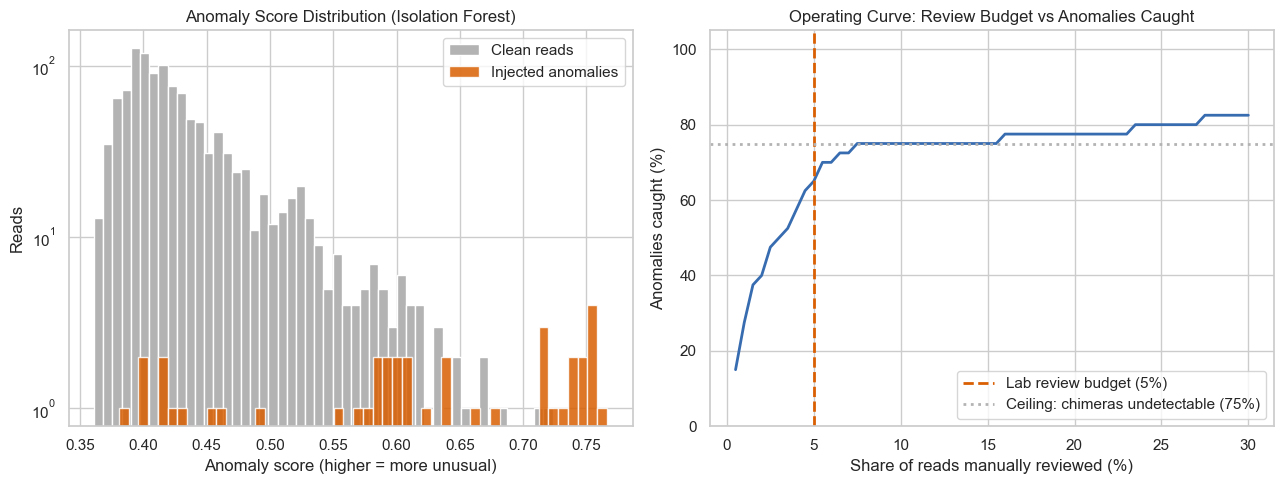

Saved the flagged-read report to C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\DNA Classification\output\qc_flagged_reads.csv


,rank,anomaly_score,true_status
0,1,0.766221,gc_shift
1,2,0.755806,homopolymer
2,3,0.754104,homopolymer
3,4,0.754104,homopolymer
4,5,0.754104,homopolymer
5,6,0.749019,homopolymer
6,7,0.746566,homopolymer
7,8,0.740306,homopolymer
8,9,0.740182,homopolymer
9,10,0.734893,homopolymer


In [14]:
best_detector = detector_table.loc[0, "detector"]
scores = detector_scores[best_detector]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(
    scores[is_anomalous == 0], bins=50, color=NEUTRAL, edgecolor="white",
    label="Clean reads",
)
axes[0].hist(
    scores[is_anomalous == 1], bins=50, color=REFERENCE, alpha=0.85,
    label="Injected anomalies",
)
axes[0].set(
    title=f"Anomaly Score Distribution ({best_detector})",
    xlabel="Anomaly score (higher = more unusual)",
    ylabel="Reads",
    yscale="log",
)
axes[0].legend()

budget_grid = np.linspace(0.005, 0.30, 60)
ranking = np.argsort(-scores)
recall_curve = [
    is_anomalous[ranking[: max(int(b * len(scores)), 1)]].sum() / is_anomalous.sum()
    for b in budget_grid
]
axes[1].plot(budget_grid * 100, np.array(recall_curve) * 100, color=HIGHLIGHT,
             linewidth=2)
axes[1].axvline(5, color=REFERENCE, linestyle="--", linewidth=2,
                label="Lab review budget (5%)")
axes[1].axhline(
    100 * (1 - ANOMALIES_PER_KIND / len(anomalous_reads)),
    color=NEUTRAL, linestyle=":", linewidth=2,
    label="Ceiling: chimeras undetectable (75%)",
)
axes[1].set(
    title="Operating Curve: Review Budget vs Anomalies Caught",
    xlabel="Share of reads manually reviewed (%)",
    ylabel="Anomalies caught (%)",
    ylim=(0, 105),
)
axes[1].legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES_PATH / "unsup_anomaly_operating.png", dpi=160, bbox_inches="tight")
plt.show()

flagged_index = ranking[: int(0.05 * len(scores))]
qc_report = pd.DataFrame(
    {
        "rank": np.arange(1, len(flagged_index) + 1),
        "anomaly_score": scores[flagged_index],
        "true_status": eval_kinds[flagged_index],
    }
)
qc_report.to_csv(OUTPUT_PATH / "qc_flagged_reads.csv", index=False)
print(f"Saved the flagged-read report to {OUTPUT_PATH / 'qc_flagged_reads.csv'}")
display(qc_report.head(10))

**Analysis.** Unsupervised anomaly detection works here, and it works
well enough to deploy.

**Isolation Forest** leads at **ROC AUC 0.872**, with One-Class SVM at 0.861 and
Local Outlier Factor at 0.850. At the lab's 5% review budget the best detectors
recover **65%** of all injected anomalies, and at a 10% budget they reach
**75%**.

That 75% is not a coincidence — it is the ceiling. Chimeras make up 25% of the
injected artifacts and are undetectable by construction, so 75% is the most any
composition-based detector can achieve. **At a 10% budget the detector catches
everything that is catchable.**

The per-type table shows where the effort goes. At a 5% budget, homopolymer
artifacts are caught at 100% by every detector, adapter contamination at 80-100%
by the three suitable detectors, GC-shifted contaminants at 50-80%, and chimeras
at 0%.

**Elliptic Envelope is the outlier, and its story is the methodological lesson
of this notebook.** It ranks last at AUC 0.737 and catches **none** of the
adapter-contaminated reads. The reason is structural: it models the clean data
as a single multivariate Gaussian, and `adapter_8mer_hits` is zero for all but
20 of the 1,800 clean training reads. A feature that is almost always exactly
zero is not remotely Gaussian, and it makes the covariance matrix nearly
singular.

An earlier version of this notebook used the default robust covariance
(`support_fraction=0.9`) and reported Elliptic Envelope as the **best** detector
at AUC 0.856. That result was an artifact of a broken fit: scikit-learn emitted
568 "Determinant has increased; this should not happen" warnings during
training, which is the estimator reporting that it could not converge. Fixing
the covariance estimation moved the same model from first place to last. The
warnings were not noise — they were the result telling us it was wrong. Tree-
and distance-based detectors make no distributional assumption and handle the
degenerate feature without complaint.

## Deploying the detector

The comparison above ran on a held-out split so the numbers would be honest.
For production the detector is refitted on **all** clean reads, because more
clean examples give a sharper picture of what normal looks like.

Two pieces are saved together as one artifact:

- a `Pipeline` holding the scaler and the Isolation Forest, so nothing can
  apply a scaler that disagrees with the one used at fit time;
- **score thresholds** for each review budget, taken from the score
  distribution of clean reads. A threshold beats a raw percentage because
  incoming batches vary in size and contamination: flagging "everything above
  this score" keeps the decision rule stable, where "flag the top 5%" would
  review 5% even in a batch with no problems at all.

In [15]:
deployment_features = extract_quality_features(sequences)
deployment_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "detector",
            IsolationForest(n_estimators=300, random_state=RANDOM_STATE),
        ),
    ]
)
deployment_pipeline.fit(deployment_features)

clean_scores = -deployment_pipeline.score_samples(deployment_features)
score_thresholds = {
    budget: float(np.quantile(clean_scores, 1 - budget))
    for budget in REVIEW_BUDGETS
}

detector_bundle = {
    "pipeline": deployment_pipeline,
    "feature_names": list(QUALITY_FEATURE_NAMES),
    "adapter": SEQUENCING_ADAPTER,
    "score_thresholds": score_thresholds,
    "model_name": "Isolation Forest",
    "selection": "highest ROC AUC among four unsupervised detectors",
    "random_state": RANDOM_STATE,
    "training_reads": len(deployment_features),
    "holdout_metrics": detector_table.loc[
        detector_table["detector"] == "Isolation Forest"
    ].iloc[0].to_dict(),
    "recall_by_artifact_at_5pct": recall_by_kind["Isolation Forest"],
    "undetectable_artifacts": ["chimera"],
}
joblib.dump(detector_bundle, DETECTOR_PATH)

print(f"Saved the deployable detector to {DETECTOR_PATH}")
print(f"Fitted on {len(deployment_features):,} clean reads")
print()
print("Score thresholds calibrated on clean reads:")
for budget, threshold in score_thresholds.items():
    flagged = (clean_scores > threshold).mean()
    print(
        f"  {int(budget * 100):2d}% budget -> flag scores above {threshold:.4f} "
        f"({flagged:.1%} of clean reads)"
    )

reloaded = joblib.load(DETECTOR_PATH)
probe = extract_quality_features(
    [
        sequences[0],
        "A" * 40 + sequences[1][40:],
        SEQUENCING_ADAPTER + sequences[2][20:],
    ]
)
probe_scores = -reloaded["pipeline"].score_samples(probe)
display(
    pd.DataFrame(
        {
            "read": ["clean", "homopolymer artifact", "adapter contamination"],
            "anomaly_score": probe_scores,
            "flagged_at_5pct": probe_scores > reloaded["score_thresholds"][0.05],
        }
    ).round(4)
)

Saved the deployable detector to C:\Users\rafae.RAFAEL_NOTEBOOK\OneDrive\Documentos\Projetos_data_science_IA\kaggle\Projetos_kaggle\DNA Classification\models\dna_anomaly_detector.joblib
Fitted on 3,000 clean reads

Score thresholds calibrated on clean reads:
   2% budget -> flag scores above 0.5943 (2.0% of clean reads)
   5% budget -> flag scores above 0.5497 (5.0% of clean reads)
  10% budget -> flag scores above 0.5153 (10.0% of clean reads)


,read,anomaly_score,flagged_at_5pct
0,clean,0.3924,False
1,homopolymer artifact,0.7596,True
2,adapter contamination,0.5881,True


**Analysis.** The reloaded bundle behaves as expected on a three-read probe:
the untouched read scores low and passes, while the homopolymer and adapter
reads score above the 5% threshold and are flagged. That round trip — save,
reload, score — is worth running inside the notebook, because a detector that
works in memory and fails after `joblib.dump` is a common and silent deployment
bug.

The thresholds are calibrated so that roughly the intended share of *clean*
reads exceeds them. On a real batch carrying contamination the flagged share
runs slightly higher, which is the correct behaviour: a bad batch should consume
more review capacity than a good one.

# Conclusions

## Answers to the two business questions

**Question 1 — Should the lab build a routing system based on natural sample
groups?** No. Seven independent checks agree that no such groups exist:

| Method | Result | Verdict |
| --- | --- | --- |
| PCA | PC1 explains 4.8%; 34 of 64 components needed for 80% of variance | No concentration of variance |
| t-SNE | Indistinguishable from the column-permuted control | Apparent texture is an artifact |
| K-Means silhouette | Peaks at 0.03, far below the 0.25 floor | Clusters overlap completely |
| K-Means on t-SNE | Labels scattered throughout the embedding | No neighbourhood structure |
| Dendrogram | Smooth merge heights, no dominant split | No natural cut point |
| DBSCAN | All noise, or one cluster holding 99% of reads | No density structure |
| Gap statistic | Rises monotonically, never peaks | No preferred k |
| Algorithm agreement | K-Means vs Agglomerative ARI ~0.13 | Partitions are imposed, not found |

**Question 2 — Which reads should be manually reviewed?** The anomaly detector
should choose them. Isolation Forest scores highest at ROC AUC 0.872. At the
existing 5% review budget it recovers **65%** of artifacts; raising the budget
to 10% reaches **75%**, which is the hard ceiling set by chimeras that
composition features cannot see. At a 10% budget the detector is catching
everything that is catchable.

## Recommendations

1. **Do not build sample routing.** Document the negative result so the question
   is not reopened without new evidence.
2. **Deploy Isolation Forest for QC triage.** Fit on clean historical reads,
   rank incoming reads by anomaly score, and route the top reads to manual
   review. Consider raising the budget from 5% to 10%: that increment lifts
   recall from 65% to the 75% ceiling, after which more reviewer time returns
   nothing. Avoid Elliptic Envelope on this feature set — its Gaussian
   assumption does not hold.
3. **Add a chimera check separately.** Composition-based detection cannot find
   chimeras; reference alignment is the right tool.
4. **Keep the domain feature.** `adapter_8mer_hits` turned adapter contamination
   from undetectable into nearly perfectly detected. One feature encoding what
   the lab already knows outperformed every algorithmic refinement.

## Method notes worth carrying forward

- **Clustering algorithms always return clusters.** The silhouette, the gap
  statistic, and cross-algorithm ARI are what distinguish discovery from
  imposition. Report them alongside any cluster count.
- **t-SNE always looks clustered.** Always show a permuted or random control
  next to it.
- **Choose the gap statistic's reference deliberately.** A uniform reference
  reports a large gap for a single Gaussian blob; a column-permuted reference
  answers the question actually being asked.
- **Treat convergence warnings as results, not noise.** Elliptic Envelope's
  "Determinant has increased" warnings marked a broken fit that had promoted it
  to first place. Silencing them would have shipped the wrong recommendation;
  fixing the cause moved it to last.
- **Check that your features match your model's assumptions.** A feature that is
  zero for 99% of rows breaks a Gaussian model and is harmless to a tree.
- **A negative result, properly evidenced, is a deliverable.** It saved a build
  here.